# 13 — Imitation

Behaviour cloning, DAgger, and what a student must be able to see ·
SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/13-imitation/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** MuJoCo renders through
    EGL on Colab, and that needs the GPU runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

It trains six small students on the CPU; the whole notebook takes a few
minutes.

## Learning from someone who already knows

Reinforcement learning discovers behaviour from a score, and weeks 8–12
showed what that costs: millions of steps, noise that destroys what it
explores, a reward that has to be exactly right.

If an **expert** already exists — a person with a joystick, a slow
planner, a hand-written controller — there is a shortcut: record what it
does and **copy it**. That is supervised learning, the easiest kind
there is.

We have three experts: the week-4 **walker**, the week-12 **policy**,
and the week-11 **planner**. We copy each one, and two of the three
copies fail. Why they fail is the lecture.

**Layer 5**: the half of modern robot learning that does not use
rewards.

------------------------------------------------------------------------

## Colour code for the week

The same colours mean the same things in every equation and every
drawing:

| symbol | meaning | colour |
|------------------------|------------------------|------------------------|
| ${\color{#2a9d5c}{a^*,\ \pi^*}}$ | the **expert**: its action, and the rule that chose it | <span style="color:#2a9d5c">green</span> |
| ${\color{#3b7dd8}{\pi_\theta,\ \theta}}$ | the **student** network and its weights | <span style="color:#3b7dd8">blue</span> |
| ${\color{#e8743b}{o}}$ | what the **student is shown** — its observation | <span style="color:#e8743b">orange</span> |
| $s$ | the robot’s full **state** (everything the simulator knows) | black |
| ${\color{#c0392b}{\varepsilon}}$ | an **error**: how often, or how much, the student is wrong | <span style="color:#c0392b">red</span> |

Two more letters, not coloured: $T$ is the **horizon** — how many
decisions an episode lasts (1000 for a 10 s walk at 100 Hz, 250 for 5 s
at 50 Hz) — and $h$ is the function that turns a state into what the
student sees, ${\color{#e8743b}{o}} = h(s)$. The expert may read all of
$s$; the student reads only ${\color{#e8743b}{o}}$. Most of today is
about the gap between the two.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"

import time, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import soc4180          # first: it selects the GL backend before mujoco loads
from pathlib import Path
from stable_baselines3 import PPO
from soc4180 import checkpoints, imitation as im
from soc4180.envs import G1PushEnv
from soc4180.walking import GaitParams
warnings.filterwarnings("ignore")
torch.set_num_threads(4)

walk_env, params = im._walker_env(), GaitParams(n_steps=40)
print(f"walker env: {1 / walk_env.control_dt:.0f} Hz, action scale {walk_env.action_scale} rad, "
      f"{walk_env.max_steps} decisions = 10 s")

walker env: 100 Hz, action scale 1.0 rad, 1000 decisions = 10 s

------------------------------------------------------------------------

## Behaviour cloning

1.  Let the expert act. At every step record the pair *(what the student
    will be shown, what the expert did)*.
2.  Fit a network to those pairs by squared error:
    $\min_{\color{#3b7dd8}{\theta}} \sum_i \lVert {\color{#3b7dd8}{\pi_\theta}}({\color{#e8743b}{o_i}}) - {\color{#2a9d5c}{a_i^*}} \rVert^2$
3.  Let the network act.

``` python
class Student(nn.Module):              # soc4180.imitation.Student
    # inputs standardised, two hidden layers of 256, ELU, 12 outputs
    @classmethod
    def fit(cls, X, Y, epochs=30):
        ...
        for _ in range(epochs):
            for b in batches:
                loss = ((s(X[b]) - Y[b]) ** 2).mean()
                opt.zero_grad(); loss.backward(); opt.step()
```

Step 2 is week 14’s `BallNet` training loop with a different $X$ and
$Y$. Nothing here needs a reward, a value function, or exploration. It
needs **examples** — and the question of *which* examples is the whole
subject.

------------------------------------------------------------------------

## Behaviour cloning, written out

**Step 1 — the data.** Run the expert; at every step $i$ keep what the
student will be shown and what the expert did:

$$\mathcal D = \big\{ ({\color{#e8743b}{o_i}},\ {\color{#2a9d5c}{a_i^*}}) \big\}_{i=1}^{N},
\qquad {\color{#e8743b}{o_i}} = h(s_i),\quad {\color{#2a9d5c}{a_i^*}} = {\color{#2a9d5c}{\pi^*}}(s_i) \in \mathbb R^{12}.$$

**Step 2 — the loss.** Squared distance between the student’s answer and
the expert’s, averaged over the $N$ examples and the 12 joints (that is
what `((s(X) - Y) ** 2).mean()` computes):

$$L({\color{#3b7dd8}{\theta}}) \;=\; \frac{1}{12N}\sum_{i=1}^{N}
\big\lVert {\color{#3b7dd8}{\pi_\theta}}({\color{#e8743b}{o_i}}) - {\color{#2a9d5c}{a_i^*}} \big\rVert^2 .$$

**Step 3 — descend it.** Pick 256 examples at random, and move the
weights a little downhill:
${\color{#3b7dd8}{\theta}} \leftarrow {\color{#3b7dd8}{\theta}} - \eta\,\nabla_\theta L_{\text{batch}}$
(the code uses Adam, a refinement of this step that rescales it per
weight; $\eta = 10^{-3}$). One pass over $\mathcal D$ is an **epoch**.

------------------------------------------------------------------------

## Behaviour cloning: the pieces, named

- ${\color{#3b7dd8}{\pi_\theta}}$ — first standardises its input,
  $({\color{#e8743b}{o}} - \mu)/\sigma$ with $\mu, \sigma$ the mean and
  spread of the training inputs, so a gyro in rad/s and a clock in
  $[-1,1]$ start on equal terms; then two layers of 256 units (ELU) and
  12 outputs.
- $\sqrt{L}$ is the **rms error** in action units — the typical size of
  the student’s mistake on one joint. For the walker one action unit is
  1 rad, so $\sqrt{L}$ is in radians; that is how the next slides read
  an MSE.

This is **ordinary regression**, the same problem as fitting a line
through points. Every difficulty today comes from *which* points are in
$\mathcal D$, not from the fitting.

------------------------------------------------------------------------

## Expert 1: the walker

The week-4 walker at 100 Hz, as `G1WalkEnv` actions — the setting at
which week 7 found it walks. Ten demonstrations, from ten slightly
different starting crouches:

In [2]:
SENSES = ["gravity", "gyro", "joints", "velocities"]
t0 = time.time()
demos = {}
for name, feats in (("sensors + clock + time", SENSES + ["clock", "time"]), ("clock + time", ["clock", "time"])):
    demos[name] = (feats, *im.walker_demos(10, feats, env=walk_env, params=params))
X = demos["clock + time"][1]
print(f"{len(X):,} examples from 10 demonstrations ({time.time() - t0:.0f} s); "
      f"each 10 s walk is 1000 decisions, the falls are shorter")

8,428 examples from 10 demonstrations (20 s); each 10 s walk is 1000 decisions, the falls are shorter

The walker is **open loop**: its action is a function of the *time*,
through the footstep plan and the LIPM, and of nothing it measures.
Three of the ten demonstrations fall (week 4 found the gait sensitive) —
they are examples too.

------------------------------------------------------------------------

## Two students

In [3]:
results = {}
for name, (feats, X, Y) in demos.items():
    s = im.Student.fit(X, Y, epochs=100)
    walks = im.walk(s, feats, env=walk_env, params=params)
    results[name] = (s.train_mse, walks)
    rms = np.sqrt(s.train_mse)
    print(f"{name:24s} training MSE {s.train_mse:.1e} = rms {rms:.4f} rad ({np.degrees(rms):.2f} deg)\n"
          f"{'':24s} walks: " + ", ".join(f"{x:+.2f} m" + (" (fell)" if n < 1000 else "") for n, x in walks))
print(f"for scale: the walker's actions themselves have rms {np.sqrt((Y ** 2).mean()):.2f} rad")

sensors + clock + time   training MSE 9.0e-06 = rms 0.0030 rad (0.17 deg)
                         walks: -0.07 m (fell), -0.05 m (fell), -0.11 m (fell)
clock + time             training MSE 1.8e-05 = rms 0.0043 rad (0.24 deg)
                         walks: +1.15 m, +1.14 m, +1.15 m
for scale: the walker's actions themselves have rms 0.18 rad

**Reading the MSE.** $\sqrt{\text{MSE}}$ is the typical mistake per
joint: a few thousandths of a radian — a quarter of a degree or less —
against actions whose own size is about 0.18 rad. Both students copy the
expert to within 2–3 % of what it does.

The student that sees **more** — every sensor, plus the clock — fits the
expert **better** and falls over within three seconds, every time.

The student that sees only the clock fits it worse, and walks exactly as
far as the walker does.

------------------------------------------------------------------------

## More information, lower error, worse robot

Measured with `imitate.py`, 10 demonstrations, 100 epochs, three starts:

| student sees            | training MSE | walks                       |
|-------------------------|--------------|-----------------------------|
| time only (1 number)    | 9.0e-3       | stands still, never falls   |
| **clock + time**        | 1.8e-5       | **1.14–1.15 m, every time** |
| sensors + clock + time  | 9.0e-6       | falls after 2.3–2.6 s       |
| … + the previous action | 3e-6         | falls after 1.5–2.8 s       |

The training error goes **down** the table and the robot gets **worse**.
Nothing about the fitting is wrong. What is wrong is the question it
answered: *“predict the expert’s action on the expert’s states”* — and
the student does not stay on the expert’s states.

------------------------------------------------------------------------

## Covariate shift

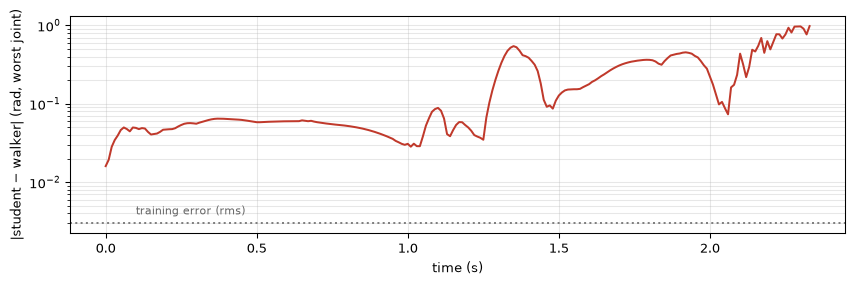

In [4]:
feats, Xs, Ys = demos["sensors + clock + time"]
s = im.Student.fit(Xs, Ys, epochs=100)
obs, _ = walk_env.reset(seed=100); gap = []
from soc4180.envs import walker_actions
from soc4180.walking import WalkingController
wc = WalkingController(walk_env.model, params)
while True:
    t = walk_env.data.time
    a_student = s.act(im.observe(obs, t, feats, params))
    a_expert = walker_actions(walk_env, wc, t)                # what the walker would do here
    gap.append((t, np.abs(a_student - a_expert).max()))
    obs, _, term, trunc, _ = walk_env.step(a_student)
    if term or trunc:
        break
gap = np.array(gap)
fig, ax = plt.subplots(figsize=(9, 3))
ax.semilogy(gap[:, 0], gap[:, 1], color="#c0392b", lw=1.5)
ax.axhline(np.sqrt(s.train_mse), color="0.5", ls=":"); ax.text(0.1, np.sqrt(s.train_mse) * 1.3, "training error (rms)", fontsize=8, color="0.4")
ax.set_xlabel("time (s)"); ax.set_ylabel("|student − walker| (rad, worst joint)"); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); plt.show()

The sensor-student’s first action is already more than a hundredth of a
radian off — five times its training error, because its own starting
crouch was never demonstrated — and within a tenth of a second the gap
is over ten times the training error. (The worst joint is plotted, so
the gap starts above the rms line even where the student is doing well.)
Each error moves the robot to a state **no demonstration visited**;
there the network is guessing, the next error is larger, and the states
drift further. The gap grows until the robot is on the floor. **Ross,
Gordon & Bagnell, 2011**: behaviour cloning’s error can grow with the
*square* of the horizon.

------------------------------------------------------------------------

## Covariate shift, drawn

The network was fitted on the states in $\mathcal D$. How far is each
state the robot actually visits from the **nearest** state in
$\mathcal D$? (Distance in the student’s own standardised inputs — the
units the network sees.)

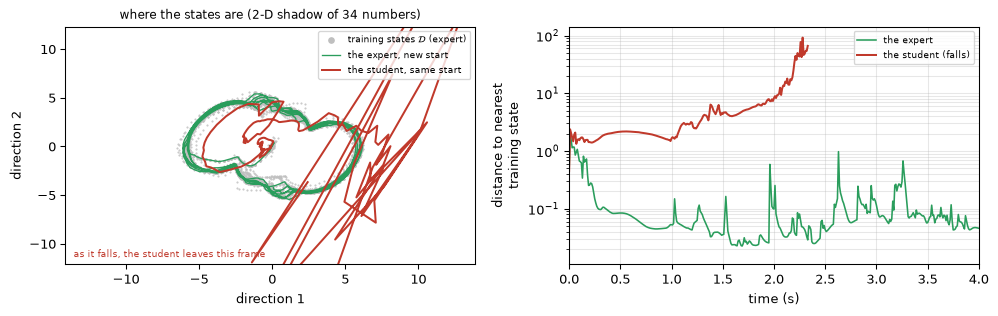

median distance: expert 0.06, student 2.85; student falls at 2.33 s, 66 units from anything it was shown

In [5]:
mu, sd = Xs.mean(0), Xs.std(0) + 1e-3
Z = (Xs - mu) / sd                                          # the training states, standardised
def nearest(x):
    return np.sqrt((((x - mu) / sd - Z) ** 2).sum(1).min())
Xe, _ = im.walker_demos(1, feats, seed=100, env=walk_env, params=params)   # the EXPERT, from a new start
obs, _ = walk_env.reset(seed=100); Xst, ts = [], []                       # the STUDENT, same start
while True:
    ts.append(walk_env.data.time); Xst.append(im.observe(obs, ts[-1], feats, params))
    obs, _, term, trunc, _ = walk_env.step(s.act(Xst[-1]))
    if term or trunc:
        break
Xst = np.array(Xst)
d_exp = np.array([nearest(x) for x in Xe]); d_stu = np.array([nearest(x) for x in Xst])
# a 2-D picture of the same thing: the two directions along which the training states spread most
U = np.linalg.svd(Z - Z.mean(0), full_matrices=False)[2][:2]
P = lambda X: ((X - mu) / sd) @ U.T
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
axes[0].plot(*P(Xs).T, ".", ms=1, color="0.75", label="training states $\\mathcal{D}$ (expert)")
axes[0].plot(*P(Xe).T, "-", lw=1, color="#2a9d5c", label="the expert, new start")
axes[0].plot(*P(Xst).T, "-", lw=1.5, color="#c0392b", label="the student, same start")
lo, hi = P(Xs).min(0), P(Xs).max(0); pad = 0.6 * (hi - lo)
axes[0].set_xlim(lo[0] - pad[0], hi[0] + pad[0]); axes[0].set_ylim(lo[1] - pad[1], hi[1] + pad[1])
axes[0].text(0.02, 0.03, "as it falls, the student leaves this frame", transform=axes[0].transAxes, fontsize=7, color="#c0392b")
axes[0].set_xlabel("direction 1"); axes[0].set_ylabel("direction 2"); axes[0].legend(fontsize=7, markerscale=8, loc="upper right")
axes[0].set_title("where the states are (2-D shadow of 34 numbers)", fontsize=9)
t_exp = np.arange(len(d_exp)) * walk_env.control_dt
axes[1].semilogy(t_exp, d_exp, color="#2a9d5c", lw=1.2, label="the expert")
axes[1].semilogy(ts, d_stu, color="#c0392b", lw=1.5, label="the student (falls)")
axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("distance to nearest\ntraining state"); axes[1].grid(alpha=0.3, which="both")
axes[1].legend(fontsize=7); axes[1].set_xlim(0, 4)
fig.tight_layout(); plt.show()
print(f"median distance: expert {np.median(d_exp):.2f}, student {np.median(d_stu):.2f}; "
      f"student falls at {ts[-1]:.2f} s, {d_stu[-1]:.0f} units from anything it was shown")

------------------------------------------------------------------------

## Reading the drawing

- **Grey**: the ${\color{#2a9d5c}{\text{expert's}}}$ distribution of
  states — the only places the network was ever taught. It is a thin
  band, because a walker repeats the same gait.
- **Green**: the expert again, from a start it has never seen. It stays
  on the band for the whole 10 s walk: its typical distance to the
  nearest example is a few hundredths.
- **Red**: the student from that same start. Its distance to the nearest
  example grows more than tenfold within two seconds, and is over a
  hundred times its starting value when it falls. Far from every
  example, the network’s output is an **extrapolation**, and nothing in
  the loss $L({\color{#3b7dd8}{\theta}})$ ever measured how good that
  is.

The name: the **covariates** (inputs) at test time come from a different
distribution than at training time. In symbols,
$d_{{\color{#3b7dd8}{\pi_\theta}}}(s) \ne d_{{\color{#2a9d5c}{\pi^*}}}(s)$
— the states *the student’s* actions lead to are not the states *the
expert’s* actions led to. Behaviour cloning optimised
$\mathbb E_{s \sim d_{\pi^*}}[\,\cdot\,]$ and is then judged on
$\mathbb E_{s \sim d_{\pi_\theta}}[\,\cdot\,]$.

------------------------------------------------------------------------

## Why errors compound: $T^2$ versus $T$

Count mistakes. Let ${\color{#c0392b}{\varepsilon}}$ be the probability
that the student gets a step wrong **on a state the expert visits**, and
suppose — the worst case — that after its first mistake it is lost and
wrong at every remaining step.

**Step 1 — the first mistake.** At step $t$ the student is still on the
expert’s states (no mistake yet), so it errs there with probability at
most ${\color{#c0392b}{\varepsilon}}$.

**Step 2 — its price.** A first mistake at step $t$ costs every step
from $t$ to $T$: at most $T - t + 1$ wrong steps.

**Step 3 — add up over $t$:**
$\;\sum_{t=1}^{T} {\color{#c0392b}{\varepsilon}}\,(T-t+1) = {\color{#c0392b}{\varepsilon}}\,\frac{T(T+1)}{2} \;=\; O({\color{#c0392b}{\varepsilon}} T^2).$

**Behaviour cloning** (Ross & Bagnell, 2010; restated in Ross, Gordon &
Bagnell, 2011), with costs in $[0, 1]$ per step:
$$J({\color{#3b7dd8}{\pi_\theta}}) \;\le\; J({\color{#2a9d5c}{\pi^*}}) + T^2\,{\color{#c0392b}{\varepsilon}} .$$

(Step 3’s sum is at most $T^2\varepsilon$, since $T(T+1)/2 \le T^2$.)
The square comes from Step 2: a mistake early in the episode is paid for
at every step that follows.

------------------------------------------------------------------------

## The two bounds, side by side

**Behaviour cloning**, from the previous slide:
$\;J({\color{#3b7dd8}{\pi_\theta}}) \le J({\color{#2a9d5c}{\pi^*}}) + T^2\,{\color{#c0392b}{\varepsilon}}$.

**DAgger** (Ross, Gordon & Bagnell, 2011, §3): trained on the student’s
*own* states, its error ${\color{#c0392b}{\varepsilon_N}}$ is measured
where it will be tested, and after enough rounds $N$ the best of its
students satisfies
$$J({\color{#3b7dd8}{\hat\pi}}) \;\le\; J({\color{#2a9d5c}{\pi^*}}) + u\,T\,{\color{#c0392b}{\varepsilon_N}} + O(1),$$
where $u$ bounds how much one wrong action can raise the expert’s
cost-to-go — how **recoverable** a mistake is.

Read with numbers: a 10 s walk at 100 Hz is $T = 1000$. One mistake in a
thousand steps (${\color{#c0392b}{\varepsilon}} = 10^{-3}$) gives a
bound of $10^{-3} \times 1000 = 1$ wrong step for DAgger’s
$T\varepsilon$ and $10^{-3} \times 1000^2 = 1000$ — the whole walk — for
$T^2\varepsilon$. These are **upper bounds** from the paper, not
measurements of our robot.

- $J(\pi)$ — the total cost of an episode run by $\pi$ (a sum of $T$
  per-step costs, each between 0 and 1)
- ${\color{#c0392b}{\varepsilon}}$ — the student’s error on the
  **expert’s** states; ${\color{#c0392b}{\varepsilon_N}}$ — its error on
  **its own** states, after $N$ rounds

The difference is not a better network. It is *where the error was
measured*: DAgger measures it on the distribution the student will
actually meet.

------------------------------------------------------------------------

## Why the clock student survives

Its input is the time. The robot’s state — however wrong — never reaches
it, so there is nothing to drift away from: it replays the walker’s
commands exactly, like a **tape recorder**.

That is also its limit. It is the week-4 walker, including every
weakness the walker had: open loop, no feedback. A 40 N sideways shove
at t = 3 s knocks it over from every start
(`imitate.py --features clock time --push 40`); holding the crouch
survives 65. It learned the expert’s *actions*, and the expert’s actions
did not contain any knowledge of balance to learn.

> A student can only learn what the expert’s decision depended on, and
> only if it can see it.

The sensor-student could see the robot’s state, but the walker’s
decision never depended on it. So the network found **accidental**
correlations — on the expert’s trajectory, knee angle predicts the next
action very well — that mean nothing off it. *Causal confusion* (de Haan
et al., 2019); the previous action is the worst offender, because on a
smooth trajectory it predicts the next action almost perfectly.

------------------------------------------------------------------------

## Expert 2: a policy

Week 12’s PPO policy, trained on randomised worlds, **is** a function of
42 numbers — it is a network that reads them. Copy it from exactly
those:

In [6]:
BASE = "https://raw.githubusercontent.com/gnoejh/soc4180/main/weeks/12-robustness/checkpoints/"
local = Path("../12-robustness/checkpoints/push_random.zip")
teacher = PPO.load(local if local.exists() else checkpoints.download("push_random.zip", BASE + "push_random.zip"),
                   device="cpu")
push_env = G1PushEnv()
ALL = ["gravity", "gyro", "joints", "velocities", "previous"]
t0 = time.time()
Xp, Yp = im.policy_demos(push_env, teacher, 40, ALL)
copy = im.Student.fit(Xp, Yp)
print(f"40 demonstrations, {len(Xp):,} examples; training MSE {copy.train_mse:.1e} ({time.time() - t0:.0f} s)")
print(f"{'survived of 20, sideways shove':34s}" + "".join(f"{p:>6} N" for p in (80, 100)))
for name, pol, f in (("the policy itself", teacher, None), ("its student", copy, ALL)):
    print(f"{name:34s}" + "".join(f"{im.shove_test(push_env, pol, f, push=p):8d}" for p in (80, 100)))

40 demonstrations, 7,368 examples; training MSE 8.4e-05 (12 s)
survived of 20, sideways shove        80 N   100 N
the policy itself                       20      16
its student                             20      12

------------------------------------------------------------------------

## When copying works

The student learns in **seconds** from 40 demonstrations what PPO needed
3 million steps to find, and it is nearly as good: every shove at 80 N,
most of them at 100.

Three things made it work, and each was missing for the walker:

1.  The expert’s action **is a function of what the student sees** —
    exactly.
2.  The expert is **deterministic**: the same state always gets the same
    answer, so there is one thing to fit, not an average of several.
3.  The expert is **closed loop**: its demonstrations include recoveries
    from the small wobbles every episode has, so the data is not a
    single thin line through state space.

This is the recipe behind most robot learning you have heard of —
**distillation**: train something expensive (an RL policy with
privileged information, a planner, a person), then copy it into
something cheap.

------------------------------------------------------------------------

## Take a sensor away

The real G1’s joint velocities come from differentiating encoder counts
and are noisy. Suppose the student may not use them — 30 numbers instead
of 42. The expert still uses all 42.

Measured with
`imitate.py --expert policy --features gravity gyro joints previous`
(100 N sideways, 20 episodes; the policy itself: 16):

| student                         | behaviour cloning | \+ 3 rounds of DAgger |
|---------------------------------|-------------------|-----------------------|
| all 42 numbers                  | 12                | —                     |
| no velocities, now only         | **0**             | 7                     |
| no velocities, **last 5 steps** | 3                 | **16**                |

With the velocities gone the expert’s decision depends on something the
student cannot see, and more data helps only a little (DAgger: 0 → 7).
Give it the last five steps of joint angles and it *can* see velocity
again — as a difference between steps — but only once DAgger shows it
the states its own mistakes lead to.

------------------------------------------------------------------------

## Why a history recovers velocity

The student is shown joint angles $q_t, q_{t-1}, \dots$ one decision
apart, $\Delta t = 0.02$ s (50 Hz). It is not shown $\dot q_t$. Can it
get it back?

**Step 1 — expand the previous angle around now** (Taylor’s theorem):
$$q_{t-1} = q(t - \Delta t) = q_t - \dot q_t\,\Delta t + \tfrac12\,\ddot q\,\Delta t^2 - \dots$$

**Step 2 — solve for the velocity:**
$$\frac{q_t - q_{t-1}}{\Delta t} \;=\; \dot q_t \;-\; {\color{#c0392b}{\tfrac12\,\ddot q\,\Delta t}} \;+\; \dots$$

The **backward difference** is the velocity plus an error of about
${\color{#c0392b}{\tfrac12\,|\ddot q|\,\Delta t}}$: small if the joint’s
speed changes little within one decision, large if it changes a lot.

**Step 3 — a network can compute it.** A first-layer unit computes a
weighted sum of its inputs. Weights $+1/\Delta t = +50$ on $q_t$ and
$-50$ on $q_{t-1}$ give exactly Step 2’s left side. So with two steps of
history the missing sensor is *representable*; whether the network
*finds* those weights is a question of data.

More steps allow better formulas — e.g.
$(3q_t - 4q_{t-1} + q_{t-2})/(2\Delta t)$ cancels the
${\color{#c0392b}{\ddot q}}$ term and leaves an error of order
$\Delta t^2$ — **if** $q(t)$ is smooth enough for the Taylor series to
be trusted. The next slide checks.

------------------------------------------------------------------------

## Finite differences, measured

One episode of the week-12 policy (nominal world, an 80 N shove), with
the velocities it was given and the ones a history would give:

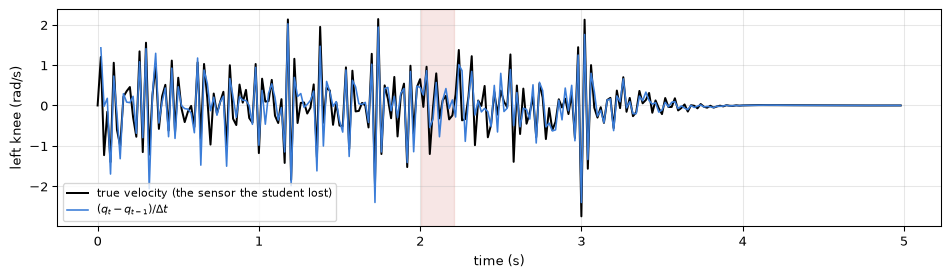

all 12 joints, 250 decisions:  velocity rms 0.75 rad/s, acceleration rms 69 rad/s^2 (from successive velocities)
  backward difference   error rms 0.66   (Step 2 predicts about 1/2 rms(qdd) dt = 0.69)   correlation 0.87
  three-point formula   error rms 1.64

In [7]:
Xv, _, _ = im._run(push_env, teacher, None, ["joints", "velocities"], 1, seed=5000,
                   world=dict(friction=1.0, mass=0.0, kp=1.0), push=80.0)
Xv = np.array(Xv); q, v = Xv[:, :12], Xv[:, 12:]
dt = push_env.control_dt
back = (q[1:] - q[:-1]) / dt                                  # two steps of history
second = (3 * q[2:] - 4 * q[1:-1] + q[:-2]) / (2 * dt)         # three steps
qdd = (v[1:] - v[:-1]) / dt                                   # how fast the velocity itself changes
rms = lambda e: np.sqrt(np.mean(e ** 2))
j = 3                                                          # left knee
t = np.arange(len(q)) * dt
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, v[:, j], color="k", lw=1.5, label="true velocity (the sensor the student lost)")
ax.plot(t[1:], back[:, j], color="#3b7dd8", lw=1.2, label="$(q_t - q_{t-1})/\\Delta t$")
ax.axvspan(push_env.push_time, push_env.push_time + 0.2, color="#c0392b", alpha=0.12)
ax.set_xlabel("time (s)"); ax.set_ylabel("left knee (rad/s)"); ax.legend(fontsize=8, loc="lower left"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
print(f"all 12 joints, {len(q)} decisions:  velocity rms {rms(v):.2f} rad/s, "
      f"acceleration rms {rms(qdd):.0f} rad/s^2 (from successive velocities)")
print(f"  backward difference   error rms {rms(back - v[1:]):.2f}   "
      f"(Step 2 predicts about 1/2 rms(qdd) dt = {0.5 * rms(qdd) * dt:.2f})   "
      f"correlation {np.corrcoef(back.ravel(), v[1:].ravel())[0, 1]:.2f}")
print(f"  three-point formula   error rms {rms(second - v[2:]):.2f}")

------------------------------------------------------------------------

## Reading the measurement

- The backward difference **follows** the true velocity (correlation
  near 0.9) but is far from exact — its error is a large fraction of the
  signal.
- Step 2 predicted the size of that error,
  ${\tfrac12\,|\ddot q|\,\Delta t}$, from nothing but the data: the two
  numbers printed agree closely. The error is not noise; it is the
  Taylor term.
- The “better” three-point formula is **worse**. It assumes $q(t)$ is
  smooth over 0.04 s, and this robot’s joints are not: the policy sends
  a new target every 20 ms, and at the acceleration printed above a
  joint’s speed changes by $|\ddot q|\,\Delta t$ — comparable to the
  speed itself — within a single interval. A formula is only as good as
  its assumption.

So a history makes velocity **available**, roughly, not handed over. The
network must learn how to combine the steps for this robot — which it
does only from data on the states it actually visits. That matches the
table: history alone 3 / 20, history + DAgger 16 / 20.

------------------------------------------------------------------------

## DAgger

**Dataset Aggregation** (Ross, Gordon & Bagnell, 2011) fixes covariate
shift by collecting data where the *student* goes:

``` python
student = Student.fit(X, Y)                      # 1. behaviour cloning
for round in range(3):
    for episode in range(20):
        run the STUDENT (round 1: half the steps the teacher's, so it lasts)
        at every state it visits, record (what it saw, what the TEACHER would do)
    X, Y = X + new, Y + new                        # 2. the dataset only grows
    student = Student.fit(X, Y)                    # 3. retrain on everything
```

It needs an expert that can be **asked** — “what would you do *here*?” —
at any state, not just one that can perform. A recorded human
demonstration cannot be asked. A policy can. A planner can, at a price.

------------------------------------------------------------------------

## DAgger, as an algorithm

**Algorithm — DAgger** (Ross, Gordon & Bagnell, 2011)

**Given:** an expert ${\color{#2a9d5c}{\pi^*}}$ that can be *queried* at
any state; rounds $N$; mixing weights
$\beta_1, \dots, \beta_N \in [0, 1]$.

1.  $\mathcal D \leftarrow$ the expert’s own demonstrations
    $\{({\color{#e8743b}{h(s)}}, {\color{#2a9d5c}{\pi^*(s)}})\}$;
    $\;{\color{#3b7dd8}{\theta_0}} \leftarrow \arg\min_\theta L(\theta; \mathcal D)$
    — behaviour cloning.
2.  **for** $i = 1, \dots, N$:
3.  $\quad$ run the mixture $\pi_i$: at each step act with
    ${\color{#2a9d5c}{\pi^*}}$ with probability $\beta_i$, else with
    ${\color{#3b7dd8}{\pi_{\theta_{i-1}}}}$
4.  $\quad$ at **every state $s$ it visits**, record
    $({\color{#e8743b}{h(s)}},\ {\color{#2a9d5c}{\pi^*(s)}})$ — what the
    *expert* would have done there — into $\mathcal D_i$
5.  $\quad$ $\mathcal D \leftarrow \mathcal D \cup \mathcal D_i$ $\quad$
    (aggregate: nothing is thrown away)
6.  $\quad$
    ${\color{#3b7dd8}{\theta_i}} \leftarrow \arg\min_\theta L(\theta; \mathcal D)$
    $\quad$ (retrain on everything)
7.  **return** ${\color{#3b7dd8}{\pi_{\theta_N}}}$

**Here** (`imitation.dagger`): $N = 3$, $\beta_1 = 0.5$,
$\beta_2 = \beta_3 = 0$, 20 episodes per round, 30 epochs per fit.
$\beta_1 = 0.5$ keeps the first, worst student from falling in the first
second, so round 1 still reaches the shove.

Step 3 is the whole idea: the **states** come from the student, the
**labels** from the expert. Line 2 alone would be ordinary trial and
error; line 3 is what turns it into supervised learning on the right
distribution.

------------------------------------------------------------------------

## Expert 3: the planner

Week 11’s MPPI can be asked about any state — it just plans from there.
It survives 300 N. Copy it:

| episodes of 20 survived       | 60 N  | 80 N | 100 N | 120 N |
|-------------------------------|-------|------|-------|-------|
| its student, 8 demonstrations | **0** | 0    | 0     | 0     |
| hold the crouch               | 20    | 0    | 0     | 0     |

Measured with `imitate.py --expert planner` (MPPI itself stood through
150 and 300 N in week 11). Training MSE 1.1e-2 — a hundred times the
policy student’s — and a student that falls at 60 N, where doing nothing
at all survives. DAgger rounds, with MPPI labelling the student’s own
states, do not rescue it: after `--dagger 3` the student survives 2 of
20 at 60 N, and its training error *rises* each round (1.1e-2 → 2.0e-2)
— the more states it is shown, the less consistent the labels become.

------------------------------------------------------------------------

## Why the planner cannot be copied

Check it against the three conditions:

1.  **Not a function of what the student sees.** MPPI plans from the
    full simulator state — pelvis velocity, the centre of mass, contact
    — and from its own previous plan $U$, which it keeps between
    decisions. Two identical observations can get two different answers.
2.  **Not deterministic.** Each decision averages 64 random futures; ask
    twice, get two answers. The labels are noisy.
3.  **Not unimodal.** Step left or step right can both be good. Squared
    error averages them — into standing still.

Distilling planners is done — Guided Policy Search (Levine & Koltun,
2013), and the planners inside AlphaZero and TD-MPC2 are trained
*together with* the networks that copy them, so that the planner’s
answers stay consistent enough to learn. An off-the-shelf MPPI is not.

------------------------------------------------------------------------

## The rule, as mathematics

Let
$m({\color{#e8743b}{o}}) = \mathbb E\big[{\color{#2a9d5c}{a^*}} \mid {\color{#e8743b}{o}}\big]$
be the expert’s **average** action over all states that look like
${\color{#e8743b}{o}}$ to the student. For any student $f$:

**Step 1 — add and subtract $m$:**
$\;\mathbb E\lVert f({\color{#e8743b}{o}}) - {\color{#2a9d5c}{a^*}}\rVert^2
= \mathbb E\lVert \big(f({\color{#e8743b}{o}}) - m({\color{#e8743b}{o}})\big) + \big(m({\color{#e8743b}{o}}) - {\color{#2a9d5c}{a^*}}\big)\rVert^2 .$

**Step 2 — expand the square.** The cross term
$2\,\mathbb E\big[(f - m)^{\mathsf T}(m - {\color{#2a9d5c}{a^*}})\big]$
is zero: fix ${\color{#e8743b}{o}}$, and $f - m$ is a constant while
$m - {\color{#2a9d5c}{a^*}}$ averages to zero by the definition of $m$.

**Step 3 — what is left:**
$$\mathbb E\lVert f({\color{#e8743b}{o}}) - {\color{#2a9d5c}{a^*}}\rVert^2
= \underbrace{\mathbb E\lVert f({\color{#e8743b}{o}}) - m({\color{#e8743b}{o}})\rVert^2}_{\text{the student can shrink this to 0}}
\;+\; \underbrace{\mathbb E\lVert {\color{#2a9d5c}{a^*}} - m({\color{#e8743b}{o}})\rVert^2}_{{\color{#c0392b}{\text{no student can touch this}}}}$$

**The rule.** The best any student can do is $f = m$, and it copies the
expert **exactly** if and only if the second term is zero — that is, if
$${\color{#2a9d5c}{a^*}} = g({\color{#e8743b}{o}}) \ \text{ for some function } g:\qquad
h(s) = h(s') \;\Longrightarrow\; {\color{#2a9d5c}{\pi^*}}(s) = {\color{#2a9d5c}{\pi^*}}(s').$$
*Two states the student cannot tell apart must get the same expert
action.*

------------------------------------------------------------------------

## The rule, applied to the three experts

| expert | ${\color{#2a9d5c}{a^*}}$ a function of ${\color{#e8743b}{o}}$? | what the second term becomes |
|------------------------|------------------------|------------------------|
| walker, student sees the clock | **yes** — the walker’s action depends on the time only | 0; the MSE left (1.8e-5) is fitting error. It walks |
| PPO policy, student sees its 42 numbers | **yes** — the policy *is* a function of them | 0; MSE 8.4e-5, fitting error. It copies |
| PPO policy, student sees no velocities | **no** — two states with the same angles but different velocities get different actions | \> 0, until a history makes velocity visible again |
| MPPI planner | **no** — it depends on the full state, its stored plan, and random samples | \> 0: MSE 1.1e-2, *rising* as DAgger adds states |

------------------------------------------------------------------------

## Three puzzles, one line each

- **Randomness** (MPPI) puts variance in ${\color{#2a9d5c}{a^*}}$ for
  the *same* $s$ — the second term can never reach zero, and more data
  only measures it better. That fits the planner student’s training MSE
  *rising* as DAgger added states: a bigger dataset, the same floor it
  cannot get under.
- **Two good answers** (step left, step right) make $m$ their
  **average** — standing still — which may be neither.
- The condition is **necessary, not sufficient**: the sensor-student of
  the walker *could* see the time, so the rule holds for it, and it
  still fell. Covariate shift is the other half of the story.

------------------------------------------------------------------------

## Teacher and student, in production

The legged-robot recipe since 2020 (Lee et al., ANYmal; Kumar et al.,
RMA):

1.  Train a **teacher** with RL in simulation, and let it observe
    **privileged** information — terrain, friction, its true velocity,
    the push. It learns fast because it can see everything.
2.  Distill it with **DAgger** into a **student** that sees only what
    the real robot has — IMU, joint encoders — plus a **history** of
    them, from which it must *infer* what the teacher was told.
3.  Deploy the student.

Every piece of it is in today’s lecture: distillation, DAgger, a history
standing in for a missing sensor. Week 12’s `robust.py --privileged`
trains such a teacher; making it better than the policy it is compared
with is exercise 5.

------------------------------------------------------------------------

## Where imitation is going

The expert does not have to be a program:

- **Teleoperation**: a person drives the robot (ALOHA, 2023 — two arms,
  a few dozen demonstrations per task). Humans are multimodal experts,
  so students predict *distributions* — action chunks, diffusion
  policies — instead of a single mean action.
- **Video of people**: no actions recorded at all; they must be
  inferred.
- **The internet**: vision-language-action models (RT-2, OpenVLA, π0)
  are behaviour cloning on hundreds of thousands of robot episodes,
  starting from a network pretrained on images and text. That is week
  15.

All of them are behaviour cloning. All of them face today’s two
questions: *which states do the examples cover*, and *can the student
see what the expert’s decision depended on*.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/13-imitation/lab_imitate.py      # torch + SB3: uv sync --extra rl
```

A game with four students to train. **You edit only `students.py`**:
what each student is shown, how much history, how many demonstrations,
how many rounds of DAgger. `1`–`4` train and test a student (the window
freezes while it trains, then the test plays at 5×), `G` grades all
four.

| \# | Problem | What it teaches |
|------------------------|------------------------|------------------------|
| 1 | TAPE: copy the walker, walk 1 m | the student must see what the expert used — and nothing misleading |
| 2 | COPY: copy the policy, 100 N | when copying works |
| 3 | FEW: at most 2 demonstrations | DAgger buys back data: cloning 0/20, + 2 rounds 20/20 |
| 4 | BLIND: no joint velocities | history stands in for a missing sensor |

------------------------------------------------------------------------

## Lab class: `imitate.py`

``` bash
uv run weeks/13-imitation/imitate.py
uv run weeks/13-imitation/imitate.py --features clock time
uv run weeks/13-imitation/imitate.py --expert policy
uv run weeks/13-imitation/imitate.py --expert policy --features gravity gyro joints previous --history 5 --dagger 3
uv run weeks/13-imitation/imitate.py --expert planner
```

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | the expert | `WalkingController` + `walker_actions`; `PPO.load`; `planning.MPPI` |
| 2 | demonstrations | `imitation.walker_demos`, `policy_demos`, `observe` |
| 3 | cloning, DAgger | `Student.fit`, `imitation.dagger` |
| 4 | the job | `imitation.walk`, `shove_test` (`xfrc_applied` via `push_force`) |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **Noise injection (DART).** Record the walker while adding small
    random noise to the actions it *executes* (label with the clean
    action). Does the sensor-student last longer? Does it ever walk?
2.  **How many demonstrations?** Plot the COPY student’s survival at 100
    N against 5, 10, 20, 40, 80 demonstrations, with and without DAgger.
3.  **Which sensor matters?** Remove each feature group in turn from the
    COPY student. Which removal hurts most? Which does not matter at
    all?
4.  **History length.** For BLIND, try 2, 3, 5, 10 steps. Where does it
    stop helping?
5.  **A better teacher.** Train `robust.py --privileged` longer, or with
    a larger network, until it beats `push_random` at 100 N; then
    distill it into a BLIND student.
6.  **Average of two modes.** Record MPPI’s action twice at the same
    state (reset its plan in between). How different are the two
    answers?

------------------------------------------------------------------------

## Next week

**14 — Learning from pixels.** Every student today read numbers from the
robot’s own body. Next week the robot gets a camera, and the student’s
input becomes 12,288 pixels — with labels the simulator hands us for
free, and a failure the moment the world changes colour.